# SILVA Delta-Cached Equilibrium

This lab derives cached linear updates, verifies zero-threshold equivalence,
sweeps the activity-error tradeoff, and tests a convolutional cache. The
defining mechanism follows DeltaDEQ [[80]](https://jseluis.github.io/silva-networks/paper/references/#ref-80).

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[22]](https://jseluis.github.io/silva-networks/paper/references/#ref-22), [[23]](https://jseluis.github.io/silva-networks/paper/references/#ref-23), [[37]](https://jseluis.github.io/silva-networks/paper/references/#ref-37), [[80]](https://jseluis.github.io/silva-networks/paper/references/#ref-80), [[83]](https://jseluis.github.io/silva-networks/paper/references/#ref-83), [[84]](https://jseluis.github.io/silva-networks/paper/references/#ref-84), [[85]](https://jseluis.github.io/silva-networks/paper/references/#ref-85), [[86]](https://jseluis.github.io/silva-networks/paper/references/#ref-86). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(91)

from torch import nn
from silva_networks import (
    SILVADeltaEquilibrium,
    SILVADeltaOperator,
    SolverConfig,
    make_delta_heterogeneous_dataset,
)

## 1. Delta Identity

For $L(z)=Wz+b$,

$$
L(z_{k+1})=L(z_k)+W(z_{k+1}-z_k).
$$

With

$$
\Delta_\tau z_{k+1}
=\mathbf1(|z_{k+1}-z_k|>\tau)\odot(z_{k+1}-z_k),
$$

the cache update is

$$
c_{k+1}=c_k+W\Delta_\tau z_{k+1}.
$$

At $\tau=0$ this is algebraically equivalent to full linear evaluation. At
$\tau>0$ it is an approximation whose task error and exact residual must be
reported with activity.

In [3]:
data = make_delta_heterogeneous_dataset(samples=8, state_dim=6, seed=96)
recurrent = nn.Linear(6, 6, bias=False).double()
source = nn.Linear(3, 6).double()
readout = nn.Linear(6, 1, bias=False).double()
with torch.no_grad():
    recurrent.weight.copy_(torch.diag(data.rates.double()))
    source.weight.copy_(data.source.double())
    source.bias.copy_(data.bias.double())
    readout.weight.fill_(1 / 6)

model = SILVADeltaEquilibrium(
    3,
    6,
    1,
    recurrent=recurrent,
    source=source,
    activation=lambda value: value,
    readout=readout,
    delta_threshold=0.0,
    config=SolverConfig(
        solver="picard", max_iter=420, tol=1e-10, backward_mode="unrolled"
    ),
)
inputs = data.inputs.double()
model.train()
full = model(inputs, use_delta=False, return_result=True)
model.eval()
delta = model(inputs, use_delta=True, return_result=True)
agreement = torch.linalg.vector_norm(full.state - delta.state)
known_error = torch.linalg.vector_norm(delta.state - data.equilibrium.double())
assert agreement < 1e-7
assert known_error < 1e-6
print("zero-threshold full/delta agreement:", float(agreement))
print("known equilibrium error:", float(known_error))
print("exact full-map residual:", delta.exact_residual)

zero-threshold full/delta agreement: 7.121357436670394e-14
known equilibrium error: 4.1501575689028015e-07
exact full-map residual: 8.900568633903255e-11


## 2. Threshold Sweep

The exact residual is always evaluated with the ordinary full recurrent map.
The active fraction records retained coordinate changes after the initial
cache fill. Neither quantity should be replaced by a hardware-independent
speed claim.

In [4]:
thresholds = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
active = []
state_errors = []
exact_residuals = []
for threshold in thresholds:
    model.delta_operator.threshold = threshold
    value = model(inputs, use_delta=True, return_result=True)
    active.append(value.mean_active_fraction)
    state_errors.append(float(torch.linalg.vector_norm(value.state - full.state)))
    exact_residuals.append(value.exact_residual)

for row in zip(thresholds, active, state_errors, exact_residuals):
    print("threshold/activity/state error/exact residual:", row)
assert active[-1] < active[0]

threshold/activity/state error/exact residual: (0.0, 0.42907475490195834, 7.121357436670394e-14, 8.900568633903255e-11)
threshold/activity/state error/exact residual: (1e-06, 0.2486897274633123, 3.230904600861271e-05, 3.5385740491248176e-06)
threshold/activity/state error/exact residual: (1e-05, 0.24411577608142557, 0.00032580349682345667, 3.488809996171904e-05)
threshold/activity/state error/exact residual: (0.0001, 0.23377403846153874, 0.003210099201704013, 0.0003588008419832066)
threshold/activity/state error/exact residual: (0.001, 0.22039473684210475, 0.03237741836816158, 0.0034857769528748766)
threshold/activity/state error/exact residual: (0.01, 0.1866496598639458, 0.32043300977629047, 0.03477841587764915)


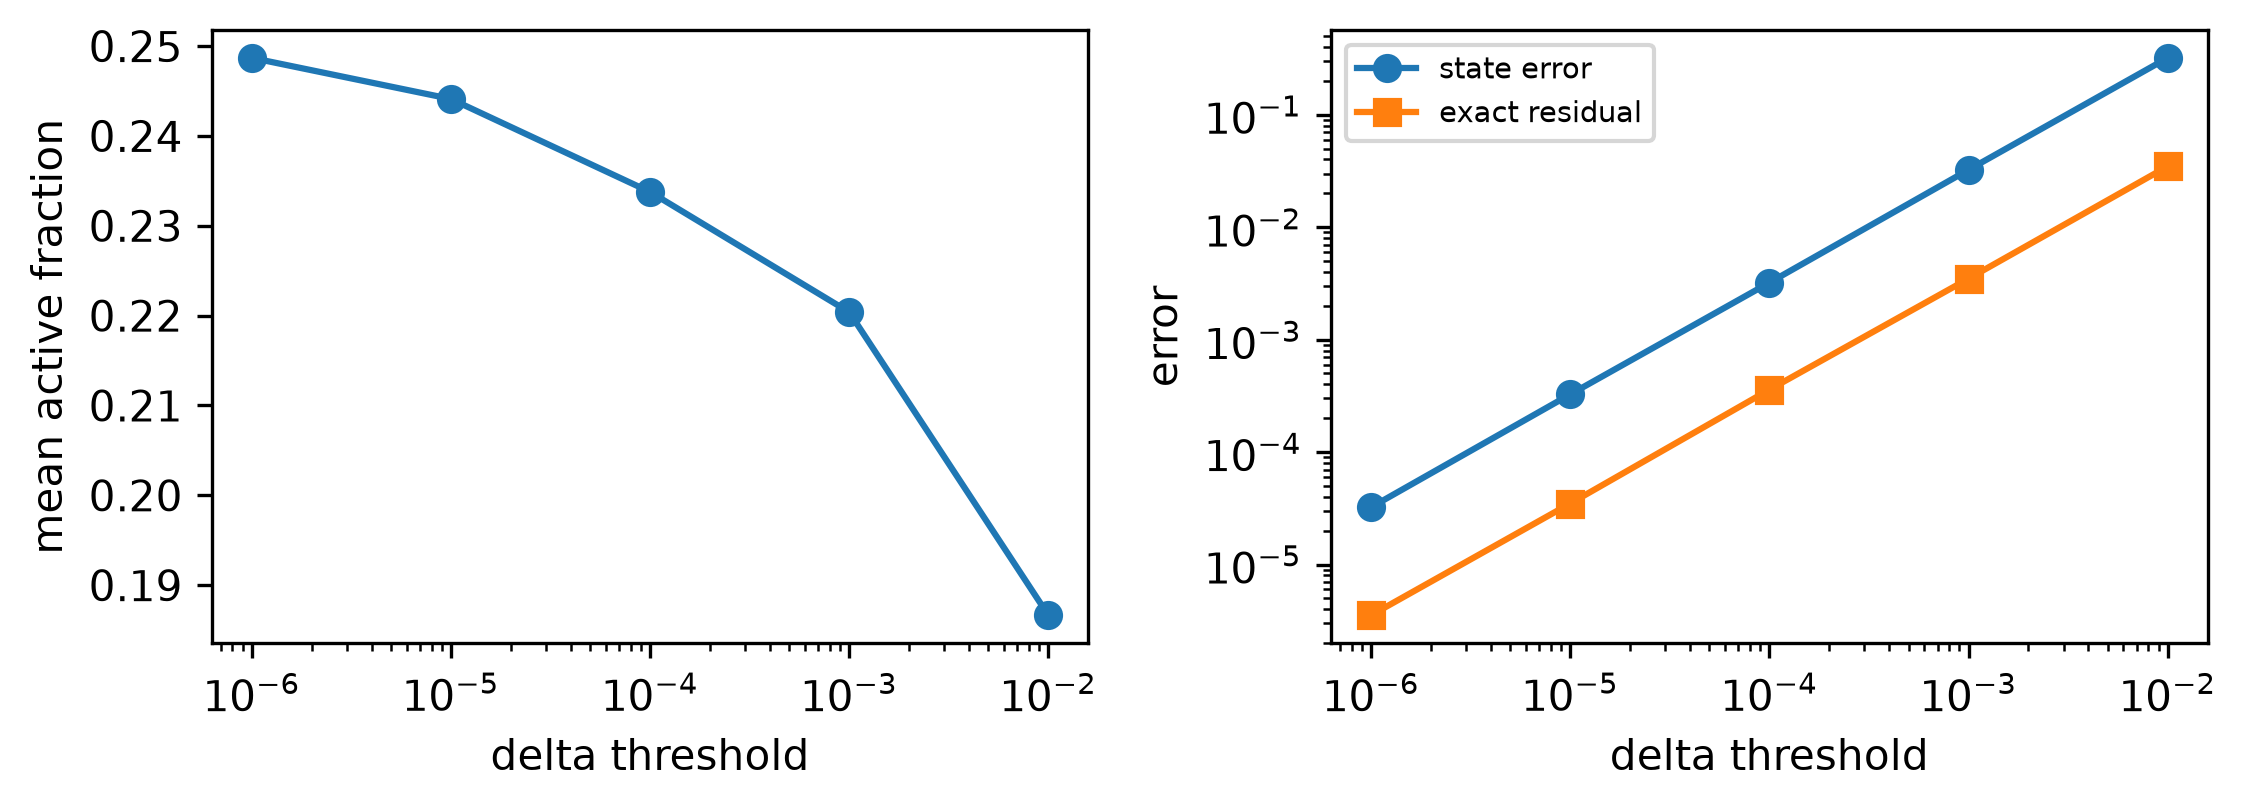

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(7.6, 2.8))
axes[0].semilogx(thresholds[1:], active[1:], marker="o")
axes[0].set(xlabel="delta threshold", ylabel="mean active fraction")
axes[1].loglog(thresholds[1:], state_errors[1:], marker="o", label="state error")
axes[1].loglog(thresholds[1:], exact_residuals[1:], marker="s", label="exact residual")
axes[1].set(xlabel="delta threshold", ylabel="error")
axes[1].legend(fontsize=7)
figure.tight_layout()
plt.show()

## 3. Why Activity Becomes Sparse

For diagonal rate $r_j$, the affine Picard error obeys

$$
e_{k,j}=r_j^k e_{0,j}.
$$

Coordinates with small $r_j$ cross a fixed delta threshold first. This is the
compact analogue of heterogeneous convergence in larger recurrent blocks.

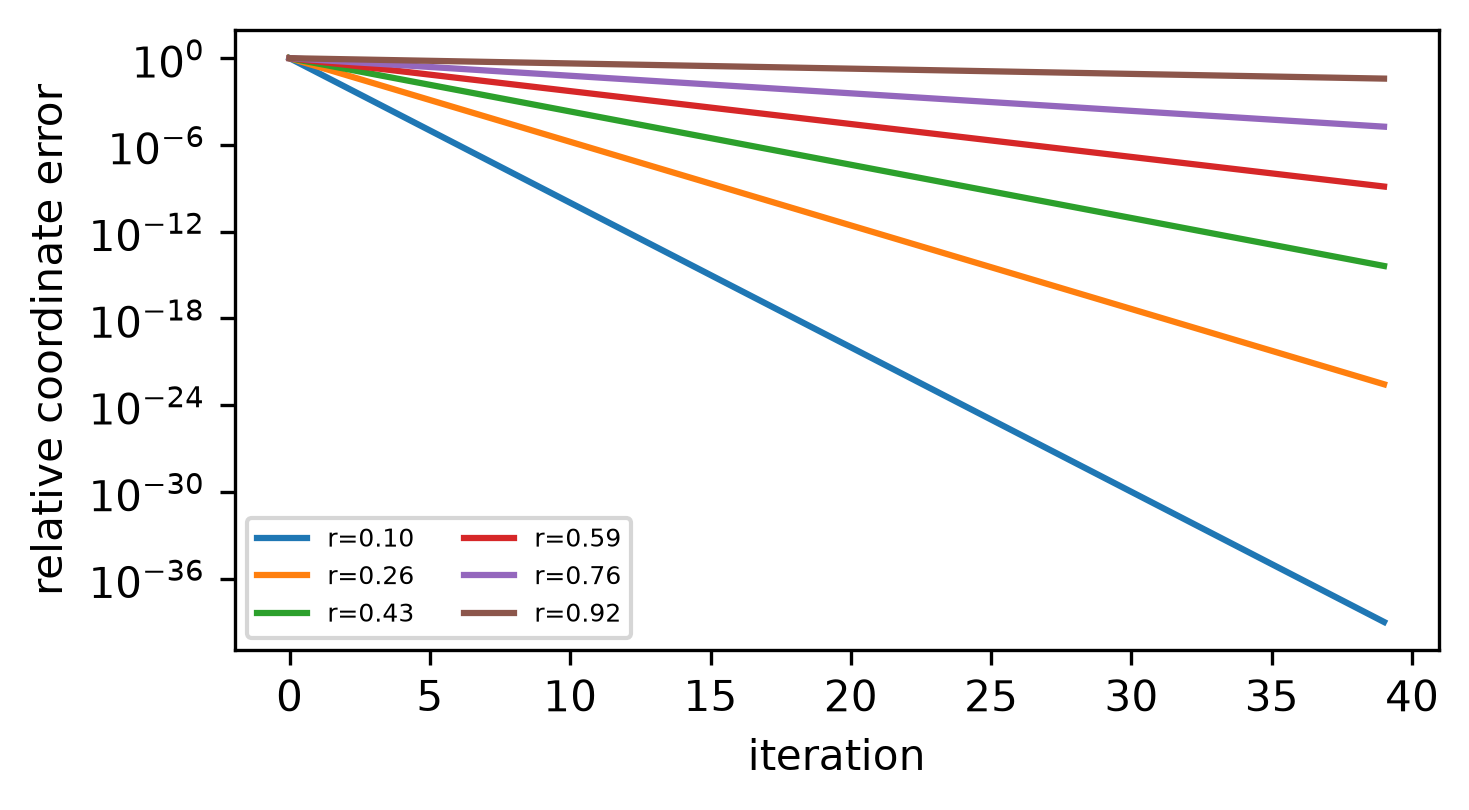

In [6]:
iterations = torch.arange(40)
figure, axis = plt.subplots(figsize=(5.0, 2.8))
for rate in data.rates:
    axis.semilogy(iterations, rate ** iterations, label=f"r={float(rate):.2f}")
axis.set(xlabel="iteration", ylabel="relative coordinate error")
axis.legend(ncol=2, fontsize=6)
figure.tight_layout()
plt.show()

## 4. Convolutional Cache

The same identity applies to convolution because convolution is linear in its
input. The bias is added once and removed from subsequent increments.

In [7]:
torch.manual_seed(97)
convolution = nn.Conv2d(2, 3, kernel_size=3, padding=1)
cached = SILVADeltaOperator(convolution, threshold=0.0)
first = torch.randn(2, 2, 8, 9)
second = torch.randn(2, 2, 8, 9)
cached(first)
cached_second = cached(second)
direct_second = convolution(second)
assert torch.allclose(cached_second, direct_second, atol=2e-6, rtol=2e-6)
print("convolution maximum difference:", float((cached_second - direct_second).abs().max()))
print("second-update active fraction:", cached.stats[-1].active_fraction)

convolution maximum difference: 4.172325134277344e-07
second-update active fraction: 1.0


## 5. Training Routes

The source-aligned experiment trains the ordinary full map and enables delta
caches only for evaluation. SILVA also permits a delta-cached forward solve
during training with implicit differentiation. In that extension, the forward
state uses the thresholded cache while the backward linear system uses the
exact full transition. Unrolled differentiation is not valid for the mutable
cache and is rejected explicitly.

In [8]:
train_model = SILVADeltaEquilibrium(
    3,
    6,
    1,
    delta_threshold=1e-4,
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-6,
        backward_mode="implicit",
        backward_solver="picard",
        backward_max_iter=40,
    ),
)
train_inputs = data.inputs.clone().requires_grad_(True)
train_model.train()
train_result = train_model(train_inputs, use_delta=True, return_result=True)
train_result.output.square().mean().backward()
assert train_inputs.grad is not None
assert train_model.recurrent.weight.grad is not None
assert train_model.source.weight.grad is not None
print("delta-forward training residual:", train_result.exact_residual)
print("input gradient norm:", float(train_inputs.grad.norm()))
print("recurrent gradient norm:", float(train_model.recurrent.weight.grad.norm()))

delta-forward training residual: 0.00019450439140200615
input gradient norm: 0.027056459337472916
recurrent gradient norm: 0.1479281485080719


## 6. Real-Image Delta Activity

The public motion snapshot contains consecutive frames 100 and 101 from the
real-video example used by the optical-flow tutorial [[86]](https://jseluis.github.io/silva-networks/paper/references/#ref-86). It has no ground-truth
flow, so this section measures only cache activity and disagreement with the
exact convolution. Sintel [[83]](https://jseluis.github.io/silva-networks/paper/references/#ref-83), KITTI Flow [[84]](https://jseluis.github.io/silva-networks/paper/references/#ref-84), or FlyingChairs [[85]](https://jseluis.github.io/silva-networks/paper/references/#ref-85) must be
loaded through `load_optical_flow_source_subset` for supervised endpoint-error
experiments.

In [9]:
from urllib.request import urlretrieve
from silva_networks import load_source_snapshot

snapshot_path = root / "docs/assets/source-data/public-motion-frames-100-101.pt"
if not snapshot_path.exists():
    snapshot_path = Path(".silva-source-data") / "public-motion-frames-100-101.pt"
    snapshot_path.parent.mkdir(parents=True, exist_ok=True)
    snapshot_url = (
        "https://raw.githubusercontent.com/jseluis/silva-networks/main/"
        "docs/assets/source-data/public-motion-frames-100-101.pt"
    )
    urlretrieve(snapshot_url, snapshot_path)

source_sample = load_source_snapshot(snapshot_path)
print("dataset:", source_sample.receipt.dataset)
print("source indices:", source_sample.receipt.selected_indices)
print("content SHA-256:", source_sample.receipt.content_sha256)
print("preprocessing:")
for step in source_sample.receipt.preprocessing:
    print(" -", step)

dataset: PublicBasketballMotion
source indices: (100, 101)
content SHA-256: 60fc2bf375ae4ffe819b135b2580d1dc25b34617b20e8f41f900055338cd8d96
preprocessing:
 - selected consecutive real-video frames
 - scaled uint8 values to [0, 1]
 - bilinear resize to 96x160


In [10]:
real_first = source_sample.tensors["frame1"]
real_second = source_sample.tensors["frame2"]
torch.manual_seed(98)
real_convolution = nn.Conv2d(3, 6, kernel_size=3, padding=1)
thresholds = [0.0, 1e-4, 1e-3, 1e-2]
real_activity = []
real_errors = []
real_max_errors = []
for threshold in thresholds:
    real_cache = SILVADeltaOperator(real_convolution, threshold=threshold)
    real_cache(real_first)
    cached_second = real_cache(real_second)
    exact_second = real_convolution(real_second)
    real_activity.append(real_cache.stats[-1].active_fraction)
    real_errors.append(
        float(torch.linalg.vector_norm(cached_second - exact_second).detach())
    )
    real_max_errors.append(
        float((cached_second - exact_second).abs().max().detach())
    )

for row in zip(thresholds, real_activity, real_errors, real_max_errors):
    print("threshold/activity/error norm/maximum error:", row)
assert real_max_errors[0] < 1e-6

threshold/activity/error norm/maximum error: (0.0, 0.7569661458333333, 1.0371226380812004e-05, 2.980232238769531e-07)
threshold/activity/error norm/maximum error: (0.0001, 0.7549696180555555, 1.0372423275839537e-05, 2.980232238769531e-07)
threshold/activity/error norm/maximum error: (0.001, 0.6834635416666667, 0.03488311171531677, 0.0011234879493713379)
threshold/activity/error norm/maximum error: (0.01, 0.29375, 0.5870646238327026, 0.01255325973033905)


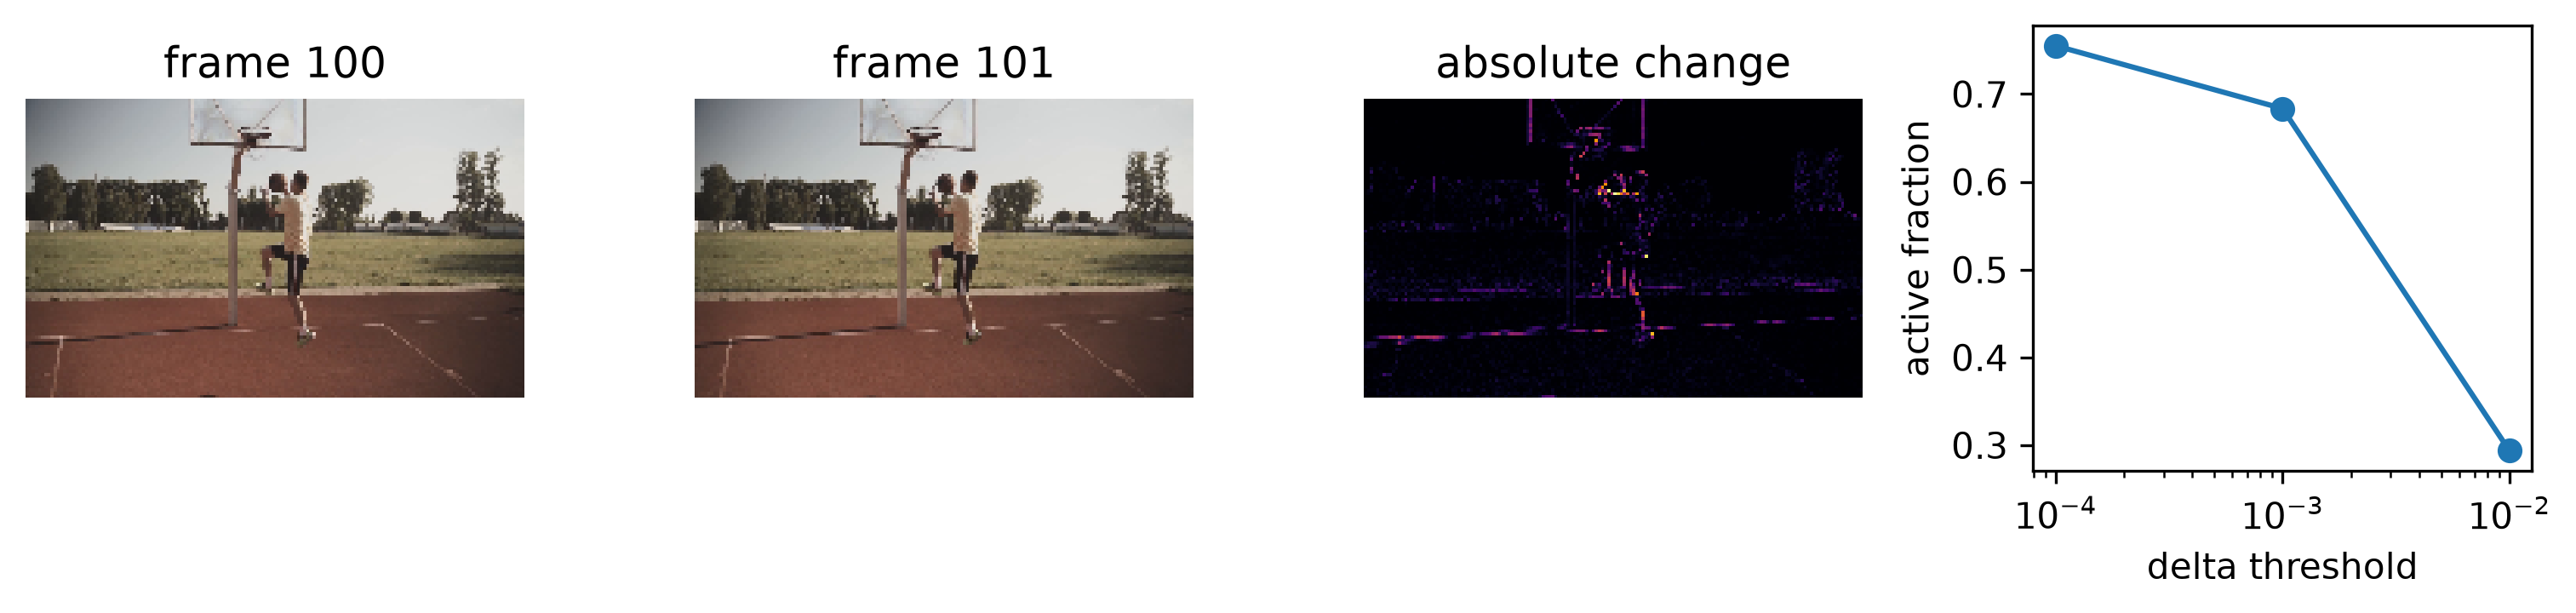

In [11]:
difference = (real_second - real_first).abs().mean(dim=1)[0]
figure, axes = plt.subplots(1, 4, figsize=(10.2, 2.5))
axes[0].imshow(real_first[0].permute(1, 2, 0))
axes[0].set_title("frame 100")
axes[1].imshow(real_second[0].permute(1, 2, 0))
axes[1].set_title("frame 101")
axes[2].imshow(difference, cmap="inferno")
axes[2].set_title("absolute change")
axes[3].semilogx(thresholds[1:], real_activity[1:], marker="o", label="activity")
axes[3].set(xlabel="delta threshold", ylabel="active fraction")
for axis in axes[:3]:
    axis.axis("off")
figure.tight_layout()
plt.show()

## Source-Scale Reproduction Contract

The compact run above verifies the defining mechanism, shapes, diagnostics,
and gradients. A published benchmark requires the source data, preprocessing,
architecture dimensions, optimization schedule, seeds, and evaluation budget.
The executable registry keeps those obligations beside the constructor.

In [12]:
from silva_networks import silva_reproduction_spec

spec = silva_reproduction_spec('silva_delta_equilibrium')
print("equation:", spec.equation)
print("datasets:", spec.datasets)
print("data sources:")
for value in spec.data_sources:
    print(" -", value)
print("source-scale steps:")
for index, value in enumerate(spec.source_scale_steps, start=1):
    print(f" {index}. {value}")
print("metrics:", spec.metrics)
print("preserved mechanisms:", spec.preserved_mechanisms)
print("SILVA extension points:", spec.silva_extensions)
print("benchmark obligations:", spec.benchmark_requirements)
print("constructor:", spec.constructor_signature)

equation: c_k=c_(k-1)+W mask(|z_k-z_(k-1)|>tau)(z_k-z_(k-1))
datasets: ('FlyingChairs', 'Sintel', 'KITTI', 'compact heterogeneous-rate equilibria')
data sources:
 - https://papers.nips.cc/paper_files/paper/2024/hash/69f5b860d6dc469ac6e52f03866b73c4-Abstract-Conference.html
 - https://github.com/ZuowenWang0000/Delta-Deep-Equilibrium-Models
source-scale steps:
 1. Load a source-compatible checkpoint and reproduce the task data preprocessing and ordinary full-map evaluation first.
 2. Wrap supported recurrent linear or convolutional operators, begin at zero threshold, and verify prediction/state equivalence and exact residual.
 3. Sweep thresholds and report task degradation, active fraction, wall time, memory traffic, solver evaluations, and hardware details.
metrics: ('task metric', 'active fraction', 'exact full-map residual', 'latency and memory traffic')
preserved mechanisms: ('cached linear or convolutional recurrent output updated from thresholded state deltas', 'zero-threshold alg

## From 41 Silva Delta Equilibrium to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Place Delta Caches Inside a Source-Compatible Transition

```python
model = SILVADeltaEquilibrium(
    in_dim=input_dim,
    state_dim=state_dim,
    out_dim=output_dim,
    recurrent=my_linear_or_convolutional_operator,
    source=my_condition_source,
    activation=my_source_architecture_activation,
    readout=my_task_head,
    delta_threshold=training_threshold,
    config=implicit_solver_config,
)
result = model(batch, use_delta=True, return_result=True)
```

With implicit or phantom differentiation, the forward solve uses thresholded
cached increments while the backward map is the original full equilibrium
equation. For source architectures with several linear sub-operators, place a
`SILVADeltaOperator` around each eligible sub-operator inside the custom
transition. Reproduce fixed-point reuse, global stopping, KM damping, training
and inference thresholds, source checkpoints, hardware-aware FLOP accounting,
and the INR or optical-flow task metric.


In [13]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [14]:
notebook_reproduction_record = {
    "notebook": '41_silva_delta_equilibrium.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '41_silva_delta_equilibrium.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the tensor solved to equilibrium**, and its repeated map,
**the state-preserving transition evaluated by the root solver**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [15]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


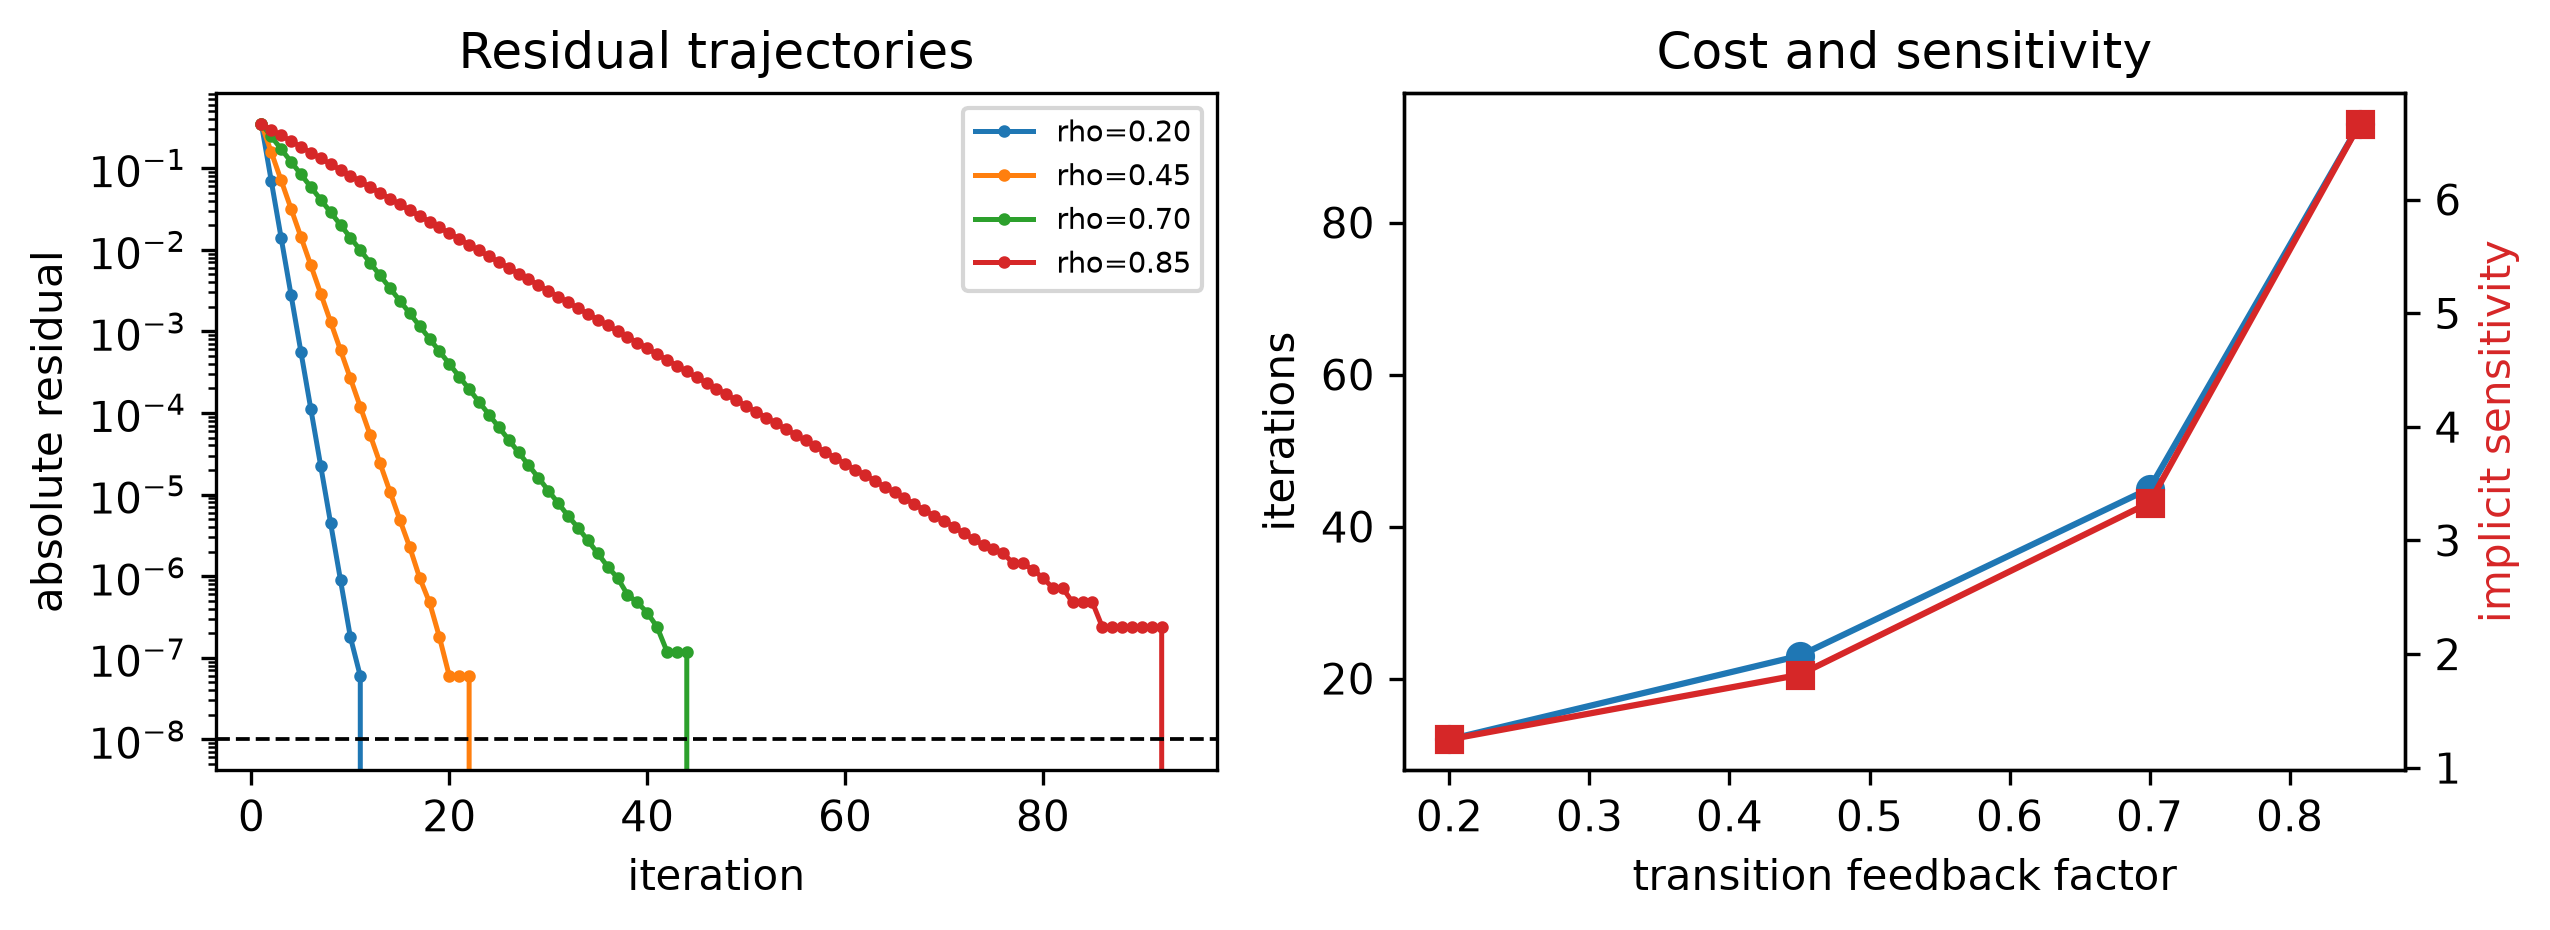

In [16]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | fixed-point residual and task error against a deterministic target |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | shape, device, dtype, finiteness, and differentiability |
| Scale sweep | Change one of state width, batch size, and data volume at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How are cached linear updates and threshold error derived? | [Structured Equilibrium Families](https://jseluis.github.io/silva-networks/learn/structured-equilibrium-families/#delta-cached-equilibrium-inference) |
| How does delta-forward implicit training work? | [Structured Equilibria API](https://jseluis.github.io/silva-networks/api/structured_equilibria/) |
| Which source-scale INR and optical-flow checks are required? | [Reproducing SILVA and Source Methods](https://jseluis.github.io/silva-networks/learn/reproducing-silva-and-papers/) |
